**Phase 3: The Training Loop**

C:\Users\rajam\miniconda3\envs\video_fusion\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Preparing Data...
Scanning data/UCF50_Tensors...
Found 6681 processed tensors.
Training on 5344 videos.
Initializing Model...
Initializing Fusion Model Components...
Loading VideoMAE weights (this happens once)...


C:\Users\rajam\AppData\Local\Temp\ipykernel_5556\421996392.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() # For Mixed Precision (Speed + Memory Saver)


Starting Training...


Epoch 1/5:   0%|                                                                              | 0/1336 [00:00<?, ?it/s]C:\Users\rajam\Desktop\Video_Action_Analysis\utils\dataset_loader.py:192: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue

...

Epoch 3 Summary -> Loss: 0.3875 | Accuracy: 90.98%


Epoch 4/5: 100%|████████████████████████████████████████████████████████| 1336/1336 [14:30<00:00,  1.53it/s, loss=1.11]


Epoch 4 Summary -> Loss: 0.2549 | Accuracy: 94.09%


Epoch 5/5: 100%|██████████████████████████████████████████████████████| 1336/1336 [14:06<00:00,  1.58it/s, loss=0.0208]


Epoch 5 Summary -> Loss: 0.2436 | Accuracy: 94.20%


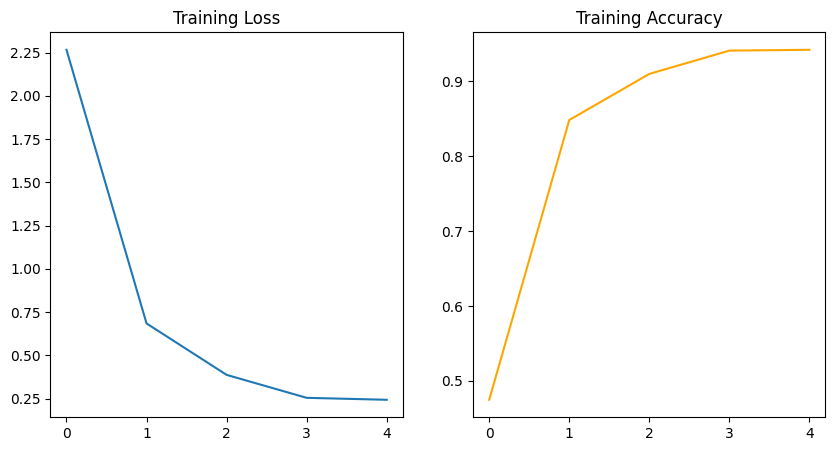

Training Complete. Model Saved.


In [1]:
# FILE: 03_Training.ipynb

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import matplotlib.pyplot as plt

# Import our custom modules
# from utils.dataset_loader import UCF50Dataset, split_dataset
from utils.dataset_loader import UCFFastDataset, split_fast_dataset
from models.fusion_model import VideoFusionModel

# --- CONFIGURATION ---
DATASET_ROOT = "data/UCF50_Tensors"
BATCH_SIZE = 4          # Keep small for GPU safety
LEARNING_RATE = 1e-4    # Small LR for fine-tuning
EPOCHS = 5              # Start with 5 to test stability
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SAVE_DIR = "checkpoints"
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. PREPARE DATA
print("Preparing Data...")
# (train_paths, train_labels), (test_paths, test_labels), class_to_idx = split_dataset(DATASET_ROOT)
(train_paths, train_labels), (test_paths, test_labels), class_to_idx = split_fast_dataset(DATASET_ROOT)

# train_dataset = UCF50Dataset(train_paths, train_labels, class_to_idx)
train_dataset = UCFFastDataset(train_paths, train_labels, class_to_idx)
# val_dataset = UCF50Dataset(test_paths, test_labels, class_to_idx) # Optional: Valid set

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
# val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Training on {len(train_dataset)} videos.")

# 2. INITIALIZE MODEL
print("Initializing Model...")
model = VideoFusionModel(num_classes=50, freeze_backbones=False).to(DEVICE)

# 3. SETUP OPTIMIZER & LOSS
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)
scaler = torch.cuda.amp.GradScaler() # For Mixed Precision (Speed + Memory Saver)

# 4. TRAINING FUNCTION
def train_one_epoch(epoch_index):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0
    
    # Progress Bar
    loop = tqdm(train_loader, desc=f"Epoch {epoch_index+1}/{EPOCHS}")
    
    for inputs, labels in loop:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        
        optimizer.zero_grad()
        
        # Mixed Precision Context
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
        # Backward Pass (Scaled)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        
        # Stats
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct_predictions += (predicted == labels).sum().item()
        total_samples += labels.size(0)
        
        # Update Progress Bar
        loop.set_postfix(loss=loss.item())
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct_predictions / total_samples
    
    return epoch_loss, epoch_acc

# 5. MAIN LOOP
loss_history = []
acc_history = []

print("Starting Training...")
for epoch in range(EPOCHS):
    loss, acc = train_one_epoch(epoch)
    
    print(f"Epoch {epoch+1} Summary -> Loss: {loss:.4f} | Accuracy: {acc*100:.2f}%")
    loss_history.append(loss)
    acc_history.append(acc)
    
    # Save Checkpoint every epoch
    torch.save(model.state_dict(), f"{SAVE_DIR}/fusion_model_epoch_{epoch+1}.pth")

# 6. PLOT RESULTS
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(loss_history, label='Loss')
plt.title('Training Loss')
plt.subplot(1, 2, 2)
plt.plot(acc_history, label='Accuracy', color='orange')
plt.title('Training Accuracy')
plt.show()

print("Training Complete. Model Saved.")